# CNN 事前学習用 問題集（宿題）

半導体デザインハッカソンでは、FPGAを搭載した評価ボード（KV260）を使って物体検出を行います。ここでは深層学習で最も大事な構成要素であるCNN（Convolutional Neural Network、畳み込みニューラルネットワーク）の基礎、及びKV260の物体検出に用いられるYOLOv3のネットワーク構成と原理についても演習を通じて学びます。

- **対象レベル**：機械学習を少しかじったことがある人。知らない用語は **検索しながら** で構いません。
- **使い方**：各章は「**解説**」→「**設問**」→「**設問の解答**」の順です。まず解説を読み、設問を自分で考えてから、解答で答え合わせをします。**解答はスクロールするとすぐ見えてしまうので、先に自分で考えてから読み進めてください。**
- **手を動かす章**：第4章はこのノートブック上で実際にCNN（LeNet）を学習・推論します。コードセルを上から順に ▶ で実行してください。**ブラウザだけ** で動き、PCへのインストールは不要です。
- **確認用セル**：計算問題（問1・3・6・9・13）の解答には、答えをPythonで計算する確認用セルを付けています。自分の計算と突き合わせてみてください。
- **このノートブックの使い方**：メニュー「ファイル → ドライブにコピーを保存」で自分のGoogleドライブにコピーしてから使うと、書き込んだ内容が保存されます。左側の目次（≡）から各章・各問に移動できます。
- **記号の約束**：本書では、入力画像の一辺を `W`、フィルタの一辺を `K`、ストライド（フィルタをずらす歩幅・後述）を `S`、パディング（入力の周囲を広げる量・後述）を `P`、入力チャネル数を `Cin`、出力チャネル数（フィルタの枚数）を `Cout` と書きます。（`S` と `P` は第1章で解説します。）

# 第1章　CNNの基礎

## 解説

**CNN** は、画像のような格子状データの認識に強いニューラルネットワークです。中心になるのが **畳み込み（convolution）** という演算です。

**畳み込みのしくみ**：小さな重みの行列（**フィルタ／カーネル**、例：3×3）を、入力画像の上で少しずつずらしながら当て、重なった部分の **掛け算の総和** を取って1つの値を出します。これを画像全体で繰り返すと、1枚の **特徴マップ（feature map）** ができます。フィルタを何種類も用意すれば、その枚数（`Cout`）だけ特徴マップが得られます。フィルタが「縦エッジ」「横エッジ」「特定の模様」などに反応し、入力のどこにその特徴があるかを表す地図になります。

**通常のニューラルネットワークと比べたメリット**：

- **パラメータ共有（重み共有）**：同じフィルタを画像全体で使い回すので、重みの数が画像サイズによらず少なくて済みます。全結合だと画素ごとに別々の重みが必要で、すぐに膨大になります。
- **局所性**：各出力は入力の **近所だけ** を見ます。画像では「近くの画素ほど関係が強い」ので理にかなっています。
- **平行移動不変性**：同じフィルタを全体に当てるので、対象が画像のどこにあっても同じように検出できます。
- **階層的な特徴抽出**：層を重ねると、浅い層はエッジなど単純な特徴、深い層は「目」「車輪」など複雑な特徴をとらえます。

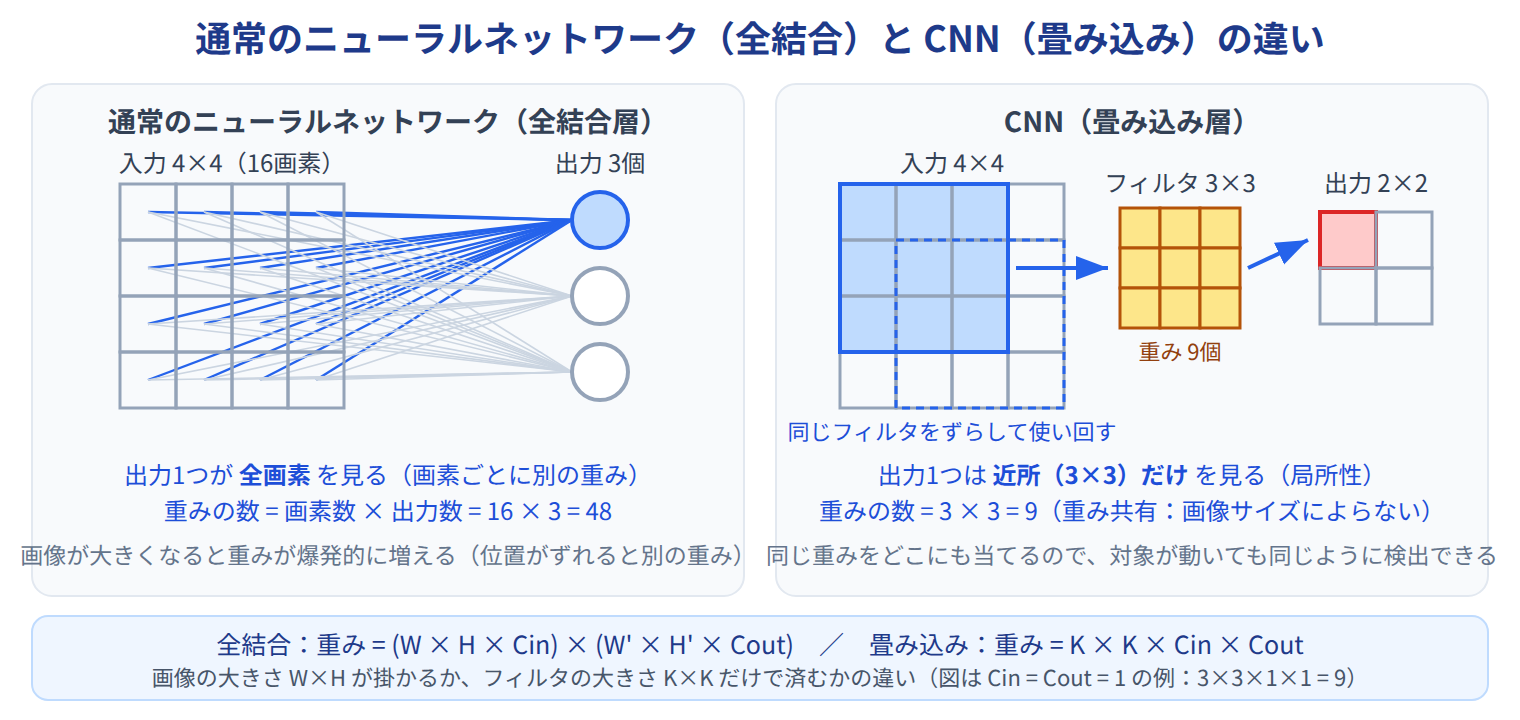

**▲ 図1：通常のニューラルネットワーク（全結合）とCNN（畳み込み）の違い。** 全結合では出力1つが全画素を見て画素ごとに別の重みを持つが、畳み込みでは出力1つが近所（`3×3`）だけを見て、同じフィルタを画像全体で使い回す。 重みの数は、全結合が `(W×H×Cin) × (W'×H'×Cout)` と画像の大きさに比例するのに対し、畳み込みは `K×K×Cin×Cout` で画像の大きさによらない（図は `Cin = Cout = 1` の例）。

**畳み込みで入力サイズはどう変わるか**：1辺の出力サイズは次式で決まります。

```
出力の1辺 O = ⌊ (W − K + 2P) / S ⌋ + 1
```

- `P`（パディング）：入力の周囲を0で囲って広げること。`P` を増やすと出力が大きくなります。
- `S`（ストライド）：フィルタをずらす歩幅。`S` を増やすと出力が小さくなります（粗くなる）。
- `K`（カーネルサイズ）：大きいほど出力は小さくなります。
- 「出力サイズを入力と同じに保つ」設定を **same** パディング（例：`K=3, S=1, P=1`）、「パディングなし」を **valid**（`P=0`）と呼びます。

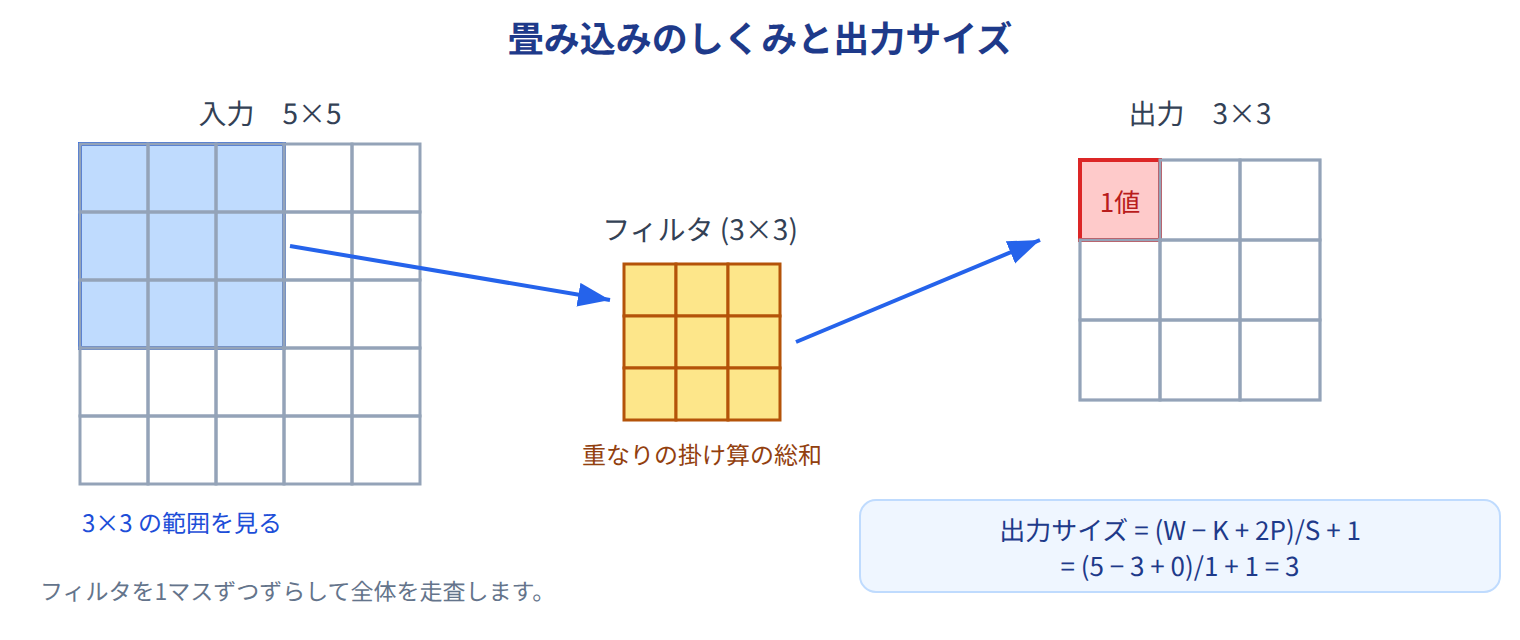

**▲ 図3：畳み込みのしくみと出力サイズ。** フィルタ（3×3）を入力の上でずらしながら、重なった部分の掛け算の総和をとって出力の1マスを作ります。`5×5` の入力を `3×3` フィルタ（ストライド1・パディングなし）で畳み込むと、出力は `3×3` になります。

また、**プーリング（pooling）** は特徴マップを縮めて情報を圧縮し、計算量を減らします。代表的な **max pooling（最大プーリング）** は、小さな窓（例：`2×2`、`S=2`）の中の **最大値** を拾って1マスにまとめます（窓ごとに最大値を選ぶので、強く反応した特徴が残る）。逆に最小値を拾う **min pooling**、平均を取る **average pooling** もあります。`2×2, S=2` なら縦横が半分になります。チャネル方向（`Cin`→`Cout`）は、フィルタの枚数で自由に変えられます。

**畳み込み層のパラメータ数**：`Cout` 枚のフィルタがそれぞれ `K×K×Cin` の重みを持ち、各フィルタにバイアスが1つ付くので、

```
パラメータ数 = (K × K × Cin + 1) × Cout
```

---

## 設問

### 問1

入力が `28×28`、フィルタ `K=5` の畳み込みを考える。次の各場合で出力の1辺はいくつになるか。
1. `P=0, S=1`
2. `P=2, S=1`
3. `P=0, S=2`

### 問2

画像認識で、全結合層だけのネットワークより **CNN（畳み込み）が有利な理由** を、「パラメータ数」と「平行移動」の2点から説明せよ。

### 問3

入力チャネル `Cin=3`（カラー画像）、出力チャネル `Cout=16`、カーネル `K=3` の畳み込み層がある。この層の **学習パラメータ数** はいくつか（バイアス含む）。同じ入出力を **全結合層** で実現しようとすると重みが何個必要になるか（入力 `32×32×3`、出力を `32×32×16` とする）と比べて、何が言えるか。

## 設問の解答

### 問1

出力公式 `O = ⌊(W − K + 2P)/S⌋ + 1`、`W=28, K=5` を使う。
1. `P=0, S=1`：`(28 − 5)/1 + 1 = 24` → **24×24**
2. `P=2, S=1`：`(28 − 5 + 4)/1 + 1 = 28` → **28×28**（sameパディング。サイズが変わらない）
3. `P=0, S=2`：`⌊(28 − 5)/2⌋ + 1 = ⌊11.5⌋ + 1 = 11 + 1 = 12` → **12×12**（ストライドで約半分に）

In [ ]:
# 問1の確認：出力サイズ公式 O = floor((W - K + 2P) / S) + 1
def out_size(W, K, P, S):
    return (W - K + 2 * P) // S + 1

W, K = 28, 5
for P, S in [(0, 1), (2, 1), (0, 2)]:
    O = out_size(W, K, P, S)
    print(f"P={P}, S={S}:  O = floor(({W} - {K} + 2*{P}) / {S}) + 1 = {O}  ->  {O}x{O}")

### 問2

- **パラメータ数**：CNNは同じフィルタを画像全体で **使い回す（重み共有）** ので、重みの数が画像サイズに比例して増えません。全結合層は入力画素ごとに別々の重みを持つため、画像が大きいと重みが爆発的に増え、学習も過学習もしやすくなります。
- **平行移動**：CNNは同じフィルタを全体に当てるので、対象が画像の **どこに移動しても同じ特徴として検出** できます（平行移動不変性）。全結合層は「どの画素にあるか」に強く依存するため、位置がずれると弱くなります。

### 問3

- 畳み込み層：`(K×K×Cin + 1) × Cout = (3×3×3 + 1) × 16 = (27 + 1) × 16 = 28 × 16 = `**448 個**。
- 全結合層で `32×32×3 = 3072` 入力 → `32×32×16 = 16384` 出力を作ると、重みは `3072 × 16384 ≈ `**約5,000万個**（バイアス除く）。
- 言えること：畳み込みは全結合に比べ **桁違いに少ないパラメータ** で画像を扱える。重み共有と局所性のおかげで、効率よく学習でき、過学習も抑えられる。

In [ ]:
# 問3の確認：畳み込み層と全結合層のパラメータ数
K, Cin, Cout = 3, 3, 16
conv_params = (K * K * Cin + 1) * Cout
print(f"畳み込み層 : (K*K*Cin + 1) * Cout = ({K}*{K}*{Cin} + 1) * {Cout} = {conv_params:,}")

n_in  = 32 * 32 * 3
n_out = 32 * 32 * 16
fc_weights = n_in * n_out
print(f"全結合層   : {n_in:,} x {n_out:,} = {fc_weights:,} 個の重み（バイアス除く）")
print(f"比         : 全結合 / 畳み込み ≈ {fc_weights / conv_params:,.0f} 倍")

# 第2章　Encoder-Decoder（応用の基本形）

## 解説

CNNの代表的な応用構造が **Encoder-Decoder（エンコーダ・デコーダ）** です。2つの部分からできています。

- **エンコーダ（符号化器）**：畳み込みとプーリング（またはストライド付き畳み込み）で、**空間サイズを徐々に小さく** しながら **チャネル数を増やし**、入力を「意味の詰まった小さな特徴（特徴ベクトル／低解像度の特徴マップ）」に圧縮します。中央の最も圧縮された部分を **ボトルネック** と呼びます。
- **デコーダ（復号化器）**：**転置畳み込み（transposed convolution）** や **アップサンプリング** で、**空間サイズを徐々に大きく** 戻し、目的の出力（画像や領域マップ）を再構成します。

**なぜ「縮めてから戻す」のか**：エンコーダで一度小さくすることで、ネットワークは「細部」ではなく「全体として何があるか」という抽象的な情報をつかみます。デコーダはその抽象情報をもとに、必要な解像度の出力を作り直します。

**応用例**：
- **セマンティックセグメンテーション**（画素ごとにクラス分け）：U-Net（図2）など。入力と同じ解像度の「ラベル地図」を出力します。
- **オートエンコーダ**：入力を一度圧縮して復元する。異常検知やノイズ除去に使われます。
- **超解像・画像生成** など。

**スキップ接続（skip connection）**：エンコーダの途中の特徴を、対応するデコーダ側に **直接つなぐ** 工夫（U-Netが有名）。エンコーダで失われがちな細かい位置情報を補い、輪郭のくっきりした出力が得られます。

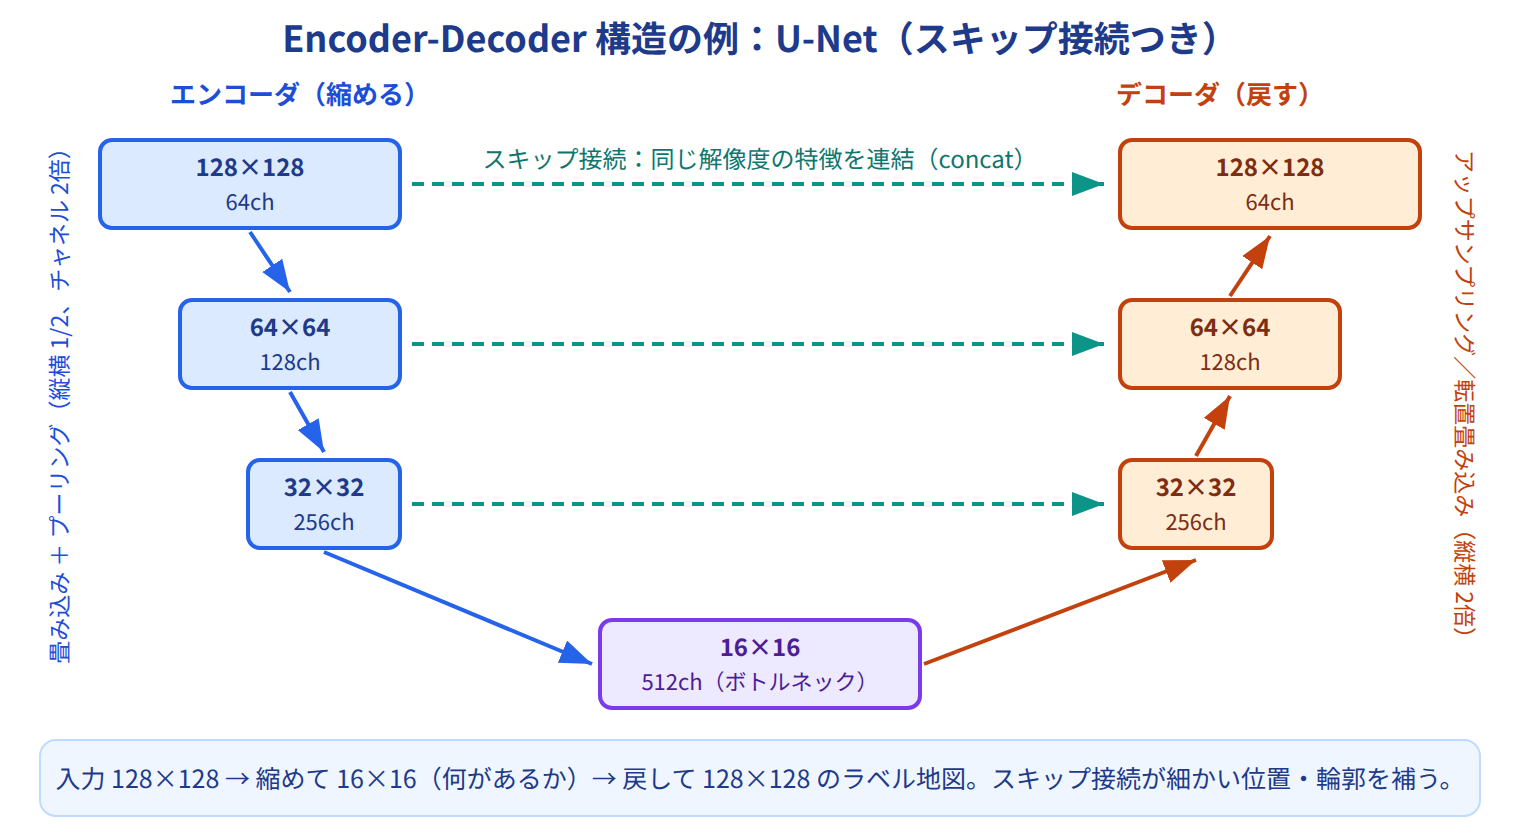

**▲ 図2：Encoder-Decoder構造の例（U-Net）。** 左のエンコーダで畳み込みとプーリングを繰り返して空間サイズを縮め（チャネル数は増やし）、中央のボトルネックを経て、右のデコーダでアップサンプリングにより元の解像度まで戻します。緑の点線が **スキップ接続** で、エンコーダの同じ解像度の特徴をデコーダ側に **連結（concat）** して細部を補います。

> YOLOv3も、深い特徴を上の解像度に戻して結合する（アップサンプリング＋連結）という、Encoder-Decoderに似た仕組みを持っています（第5章で扱います）。

---

## 設問

### 問4

Encoder-Decoder構造で、(a) エンコーダでは空間サイズとチャネル数がそれぞれどう変化するか、(b) デコーダで空間サイズを大きく戻すために使う代表的な演算は何か、を答えよ。

### 問5

U-Netなどで使われる **スキップ接続** は、何のために、どんな情報を補うのか説明せよ。

## 設問の解答

### 問4

- (a) エンコーダでは、**空間サイズ（縦横）は小さくなり**、**チャネル数は増える**。情報を「広く浅い画像」から「狭く深い特徴」へ圧縮していく。
- (b) デコーダで空間サイズを大きく戻すには、**転置畳み込み（transposed convolution、別名 deconvolution）** や **アップサンプリング（最近傍・バイリニア補間など）** を使う。

### 問5

スキップ接続は、エンコーダの途中の **高解像度の特徴（細かい位置・輪郭の情報）** を、デコーダの対応する層に **直接渡す** ためのもの。エンコーダで圧縮する過程で失われがちな細部を補い、輪郭のはっきりした、位置精度の高い出力が得られる（セグメンテーションのU-Netが代表例）。

# 第3章　いろいろな畳み込み（グループ化・深さ方向分離）

## 解説

標準的な畳み込みは、各出力チャネルを作るために **すべての入力チャネル** を使います（フィルタは `K×K×Cin`）。これは表現力が高い一方で、計算量とパラメータが多くなりがちです。そこで、計算を軽くする変種があります。

**グループ畳み込み（grouped convolution）**：入力チャネルを `G` 個の **グループに分け**、グループの中だけで畳み込みます。グループ間はまざりません。パラメータと計算量は **およそ `1/G`** になります。古くはAlexNet（GPU2枚に分けるため）、最近ではResNeXtなどで使われます。

**深さ方向畳み込み（depthwise convolution）**：グループ畳み込みの極端な場合で、**`G = Cin`**（＝チャネルごとに専用の1枚のフィルタ）。各チャネルを独立に空間方向だけ畳み込み、**チャネル間の混ぜ合わせはしません**。

**点ごとの畳み込み（pointwise convolution）**：`1×1` の畳み込み。空間方向には混ぜず、**チャネル方向だけ** を混ぜ合わせます（チャネル数の増減＝次元の調整に使う）。

**Depthwise Separable Convolution（深さ方向分離畳み込み）**：**depthwise（空間を畳む）＋ pointwise（チャネルを混ぜる）** の2段に分解したもの。 depthwise は **各チャネルの面内で** `K×K` の畳み込みを行い（`M` 枚の入力から `M` 枚の出力、重み `K×K×M`）、pointwise は **各画素の深さ方向で** `M` 個の値から `N` 個の値を作る全結合演算を行う（重み `M×N`、同じ重みを全画素位置 `W×H` 回使い回すので出力は `W×H×N`）。下の参考資料では **チャンネル別畳み込み（Channel-wise Separable Convolution）** という名前で説明されていますが、同じものです（資料中の「深さ方向畳み込み」が本書の depthwise、「点単位畳み込み」が pointwise に当たります）。標準の畳み込みとほぼ同じ働きを、**ずっと少ない計算量** で実現します。MobileNetなど、スマホやエッジ向けの軽量モデルで多用されます。

**どれくらい軽くなるか**（`K×K` カーネル、入力 `Cin=M`、出力 `Cout=N`）：

```
標準畳み込みのパラメータ        ：K × K × M × N
depthwise + pointwise の合計   ：K × K × M  +  M × N
比（分離 ÷ 標準）              ：1/N + 1/K²
```

`K=3`、`N` が大きいとき、比はおよそ `1/9` になり、**約8〜9倍** 軽くなります。

> **図で理解したい人へ（参考）**：各種畳み込みの図解は、zero2oneのブログ「CNNのための様々な畳み込み手法」が分かりやすいです（グループ化畳み込み・点単位畳み込み・チャンネル別畳み込み＝Depthwise Separable Convolution の3つを図とPyTorchコードで説明しています）。`https://zero2one.jp/learningblog/various-convolution-methods-for-cnn/`

**残差接続（Residual Connection）と ResNet**

ネットワークを深くするほど複雑な特徴を学べそうですが、ただ層を積み重ねると、かえって学習がうまくいかなくなります。何が起きているのかを見てみましょう。

**学習のしくみと「勾配が消える」**：ニューラルネットワークの学習は、出力の誤差を **出口から入口へ向かって逆向きに伝え**、各層に「重みをどちらへどれだけ直せばよいか」を知らせることで進みます（誤差逆伝播）。この「直す方向と量」の信号が **勾配** です。信号は層を1つさかのぼるたびに、その層の重みや活性化関数の傾きを **掛け算** されます。この掛け算の係数が平均して 1 より少し小さい（たとえば 0.9）だけでも、50層さかのぼると `0.9^50 ≈ 0.005` となり、入口に近い層には信号がほとんど届きません。伝言ゲームで、人を経るたびに声が小さくなり、最初の人には何も聞こえないような状態です。信号が届かない浅い層は重みを直せないので、深くしたのに **学習が進まない** ことになります（逆に係数が 1 より大きいと信号が爆発します）。

**「劣化問題」**：正規化などの工夫でこの消失をある程度抑えても、なお不思議な現象が残りました。20層のネットワークより 56層のネットワークのほうが、テストだけでなく **学習データに対する誤差まで大きくなる** のです。過学習ではありません。理屈のうえでは、56層のうち 20層を元と同じにし、残り 36層を「入力をそのまま通す層（恒等写像 `H(x) = x`）」にすれば少なくとも 20層と同じ性能が出るはずです。ところが、畳み込みと非線形関数を重ねた普通の層で「入力をそのまま返す」変換をぴったり学習するのは意外に難しく、ランダムな初期値から始めた最適化はそこにたどり着けません。深くすると、**余分な層が「何もしない」ことすらできずに邪魔をする** のが劣化問題です。

**残差接続はこう解決する**：普通の層は、目標の変換 `H(x)` を直接学ぼうとします。残差ブロックは代わりに **差分 `F(x) = H(x) − x`** を学び、入力 `x` を **ショートカットでそのまま足して** `出力 = F(x) + x` を作ります。これで上の2つの問題が同時に解けます。

- **劣化問題に対して**：「何もしない」が `F(x) = 0`、つまり重みをゼロに近づけるだけでよくなります。これは簡単なので、余分な層は最初から「ほぼ素通し」として振る舞い、必要な分だけ差分を学びます。層を増やしても悪化しにくくなります。
- **勾配消失に対して**：出力 `F(x) + x` を `x` で微分すると `F'(x) + 1` になり、この **`+1` の分はショートカットを通って係数を掛けられずにそのまま前の層へ届きます**。伝言ゲームでいえば、口伝えと並行して **原文のコピーも一緒に回す** ようなもので、何十層さかのぼっても信号が消えません。

この仕組みのおかげで ResNet-50/101/152 のような深いネットワークが実現しました。YOLOv3のバックボーン **Darknet-53** も、この残差ブロックを多数積み重ねた構造です。

> 第2章のスキップ接続が特徴を **連結（concat、チャネル方向につなぐ）** するのに対し、残差接続は同じ形のまま **足し算（add）** で加える、という違いがあります。どちらも「先の情報を後ろへショートカットさせる」点は共通です。

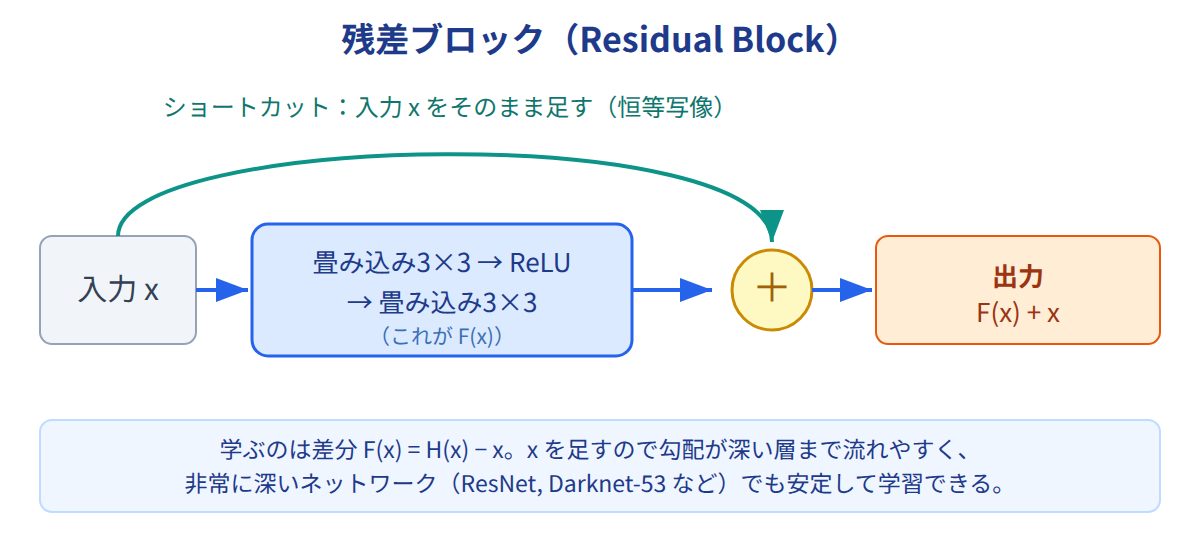

**▲ 図4：残差ブロック。** 入力 `x` を畳み込み2層 `F(x)` に通し、その出力に **ショートカットで運んだ `x` を足して** `F(x) + x` を出力します。

---

## 設問

### 問6

入力 `M=32` チャネル、出力 `N=64` チャネル、カーネル `K=3` のとき、(a) **標準畳み込み** のパラメータ数、(b) **depthwise + pointwise（分離畳み込み）** の合計パラメータ数を計算し、(c) 何倍軽くなるかを求めよ（バイアスは無視してよい）。

### 問7

(a) グループ畳み込みで `G`（グループ数）を大きくすると、計算量・パラメータはどう変わるか。(b) depthwise畳み込みは `G` がいくつのグループ畳み込みに当たるか。(c) depthwiseだけでは不十分で、後ろに `1×1`（pointwise）畳み込みを付けるのはなぜか。

### 問8

**残差接続（residual connection）** について、(a) 層をただ深く積み重ねると起きる問題は何か、(b) 残差ブロックはそれをどう解決するか（`出力 = F(x) + x` の意味を含めて）、(c) 第2章のスキップ接続（連結）との違いは何か、を答えよ。

## 設問の解答

### 問6

`K=3, M=32, N=64`。
- (a) 標準畳み込み：`K×K×M×N = 3×3×32×64 = 18,432`。
- (b) depthwise：`K×K×M = 3×3×32 = 288`。pointwise：`M×N = 32×64 = 2,048`。合計 `288 + 2,048 = 2,336`。
- (c) `18,432 ÷ 2,336 ≈ 7.9` → **約8倍軽い**。公式どおり `1/N + 1/K² = 1/64 + 1/9 ≈ 0.127`（≈ 1/7.9）と一致する。

In [ ]:
# 問6の確認：標準畳み込み vs depthwise + pointwise
K, M, N = 3, 32, 64
standard  = K * K * M * N
depthwise = K * K * M
pointwise = M * N
separable = depthwise + pointwise
print(f"(a) 標準畳み込み      : {K}*{K}*{M}*{N} = {standard:,}")
print(f"(b) depthwise {depthwise} + pointwise {pointwise:,} = {separable:,}")
print(f"(c) 標準 / 分離 = {standard / separable:.2f} 倍軽い")
print(f"    公式 1/N + 1/K^2 = 1/{N} + 1/{K*K} = {1/N + 1/(K*K):.4f} （≈ 1/{1/(1/N + 1/(K*K)):.1f}）")

### 問7

- (a) グループ数 `G` を大きくすると、各グループが扱うチャネルが減るので、**計算量もパラメータもおよそ `1/G` に減る**（ただしグループ間で情報がまざらなくなる）。
- (b) depthwise畳み込みは **`G = Cin`（入力チャネル数）** のグループ畳み込みに当たる（チャネルごとに専用フィルタ1枚）。
- (c) depthwiseは各チャネルを **空間方向に畳むだけ** で、**チャネル間を混ぜない**。そのままでは「複数チャネルの情報を組み合わせた特徴」を作れないので、後ろに `1×1`（pointwise）畳み込みを付けて **チャネル方向の混ぜ合わせ** を担わせる。これで標準畳み込みに近い表現力を、軽い計算量で得られる（depthwise separable convolution）。

### 問8

- (a) 層をただ深く積み重ねると、**勾配が消えて（劣化して）学習が進みにくくなる**。深くしたのに浅いものより精度が下がる「劣化問題」も起きる。
- (b) 残差ブロックは、目標の写像 `H(x)` を直接学ぶ代わりに **差分 `F(x) = H(x) − x`** を学び、入力 `x` を **ショートカットでそのまま足して** `出力 = F(x) + x` とする。何も変えなくてよいときは `F(x) = 0`（恒等写像）を学べばよいので、層を増やしても悪化しにくい。さらにショートカットを通って勾配が深い層まで流れるため、深いネットワークでも学習が安定する。
- (c) 第2章のスキップ接続は特徴を **連結（concat、チャネル方向につなぐ）** するのに対し、残差接続は同じ形のまま **足し算（add）** で加える。どちらも先の情報を後ろへ運ぶショートカットだが、合流のしかた（つなぐ／足す）が違う。

# 第4章　LeNetでMNISTを学習する（Google Colab演習）

## 解説

ここでは、最も基本的なCNNの一つ **LeNet** を使い、手書き数字データ **MNIST**（`28×28` のグレースケール画像、0〜9の10クラス）を学習し、推論を試します。LeNetとMNISTは軽いので、**Google Colabの無料枠** でも数分で学習が終わります。

**LeNetの構造**（本演習版、入力 `1×28×28`）：

```
入力 1×28×28
 → 畳み込み conv1 (Cout=6,  K=5, P=2)  → 6×28×28
 → 最大プーリング 2×2                  → 6×14×14
 → 畳み込み conv2 (Cout=16, K=5, P=0)  → 16×10×10
 → 最大プーリング 2×2                  → 16×5×5
 → 平坦化(flatten)                     → 400
 → 全結合 fc1 (400→120) → 全結合 fc2 (120→84) → 全結合 fc3 (84→10)
 → 出力 10（各数字のスコア）
```

最後の全結合層で「0〜9のどれらしいか」を10個のスコアで出し、一番大きいものを予測とします。

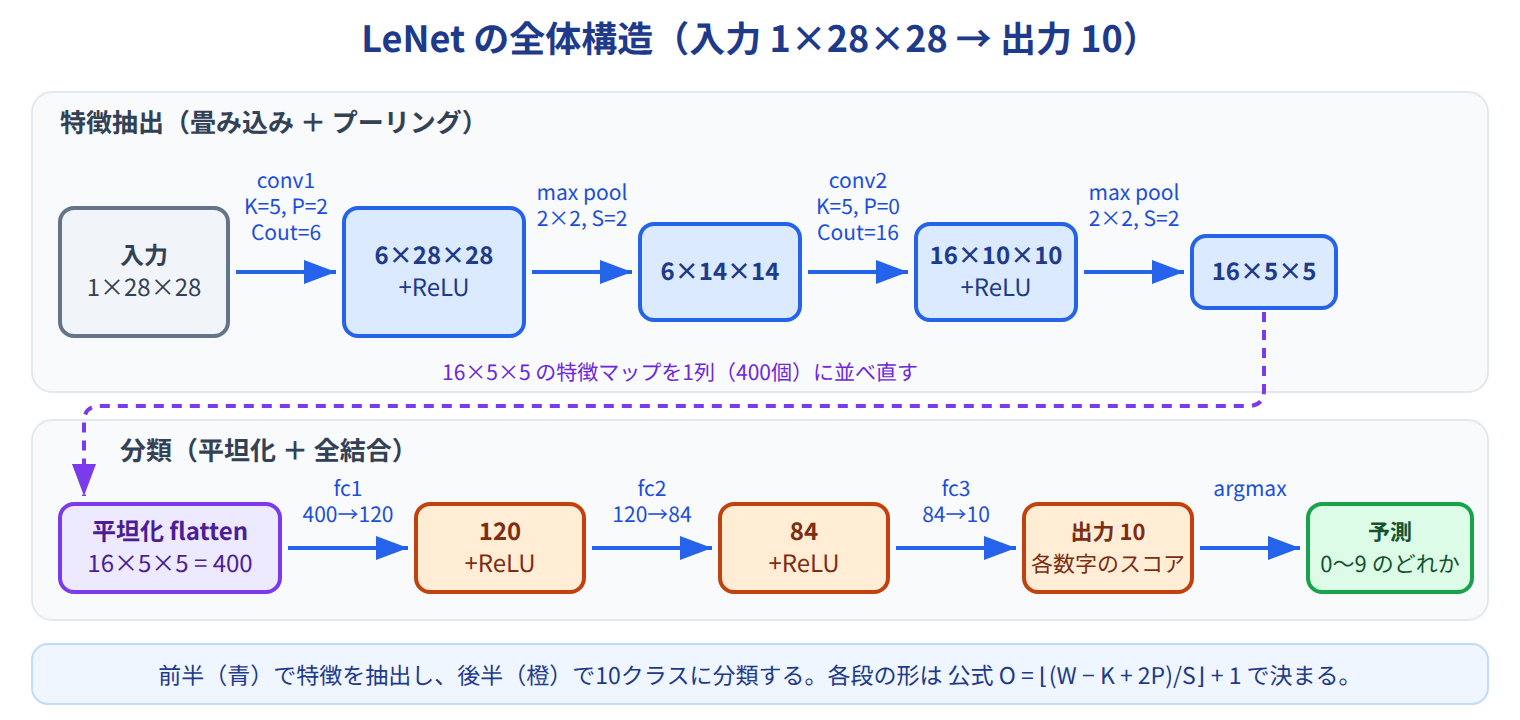

**▲ 図5：LeNetの全体構造。** 前半（青）は畳み込みと最大プーリングで特徴を抽出し、`16×5×5` の特徴マップを1列（400個）に平坦化してから、後半（橙）の全結合層3つで10クラスのスコアに変換します。各段の形が第1章の出力サイズ公式どおりになっていることを、問9で確かめます。

**進め方**：下のコードセルを **上から順に** ▶（実行）で実行してください。

- （任意）メニュー「ランタイム → ランタイムのタイプを変更」で **GPU**（T4など）を選ぶと速いです。CPUのままでも数分で終わります。
- 学習（3エポック）は GPU で 30秒〜1分、CPU で 2〜3分程度です。
- PyTorch と torchvision は Colab に最初から入っているので、インストールは不要です。

## 演習コード（PyTorch）

### (1) 準備：ライブラリの読み込みとデバイスの確認

GPUが使えれば `cuda`、使えなければ `cpu` と表示されます。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

### (2) データ準備（MNIST：初回は自動ダウンロード）

学習用6万枚・テスト用1万枚の `28×28` グレースケール画像を読み込みます。

In [ ]:
transform = transforms.ToTensor()
train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256)

print("train:", len(train_ds), "枚   test:", len(test_ds), "枚")
img, label = train_ds[0]
print("1枚の形 (チャネル×高さ×幅):", tuple(img.shape), "  ラベル:", label)

### (3) LeNet の定義

解説の構造図と、コードのコメント（各層を通ったあとの形）を対応づけて読んでください。

In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # 1x28x28 -> 6x28x28
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)            # 6x14x14 -> 16x10x10
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)  # -> 6x14x14
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)  # -> 16x5x5
        x = x.view(x.size(0), -1)                   # -> 400
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)                          # -> 10

model = LeNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print(model)
print("学習パラメータ数:", sum(p.numel() for p in model.parameters()))

### (4) 学習（3エポックでも十分高精度）

`EPOCHS` の値を変えると学習の回数を変えられます（問10で使います）。

In [ ]:
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch + 1} done, last loss = {loss.item():.4f}")

### (5) テストデータで精度を測る

うまくいけば、テスト精度はおよそ **98〜99%** になります。

In [ ]:
model.eval()
correct = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
print(f"test accuracy = {100 * correct / len(test_ds):.2f}%")

### (6) 1枚だけ推論して画像と一緒に表示

`idx` を変えると別の画像を試せます。

In [ ]:
import matplotlib.pyplot as plt

idx = 0
img, label = test_ds[idx]
model.eval()
with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"prediction = {pred}, label = {label}")
plt.axis("off")
plt.show()

---

## 設問

### 問9

上のLeNetで、入力 `1×28×28` の画像が各層を通るとき、`conv1`→プーリング→`conv2`→プーリング→平坦化、の各段階で **テンソルの形（チャネル×高さ×幅、または要素数）** がどう変わるかを順に書け。`conv1` は `K=5, P=2, S=1`、`conv2` は `K=5, P=0, S=1`、プーリングは `2×2, S=2` とする（第1章の出力サイズ公式を使う）。

### 問10

実際にColabでコードを動かし、(a) 表示された **テスト精度** を書け。(b) 学習の `for epoch in range(3)` を `range(1)` に変える（1エポックだけにする）と精度はどうなりそうか、予想して実際に確かめよ。

## 設問の解答

### 問9

- 入力：`1×28×28`
- `conv1`（`K=5,P=2,S=1`、`Cout=6`）：`(28−5+4)/1+1 = 28` → **`6×28×28`**
- プーリング `2×2,S=2`：縦横half → **`6×14×14`**
- `conv2`（`K=5,P=0,S=1`、`Cout=16`）：`(14−5)/1+1 = 10` → **`16×10×10`**
- プーリング `2×2,S=2`：→ **`16×5×5`**
- 平坦化（flatten）：`16×5×5 = ` **`400`**（→ 全結合 `fc1` の入力）

In [ ]:
# 問9の確認：実際のテンソルの形を各段階で表示する（(3) の model を使う）
x = torch.zeros(1, 1, 28, 28).to(device)   # バッチサイズ1のダミー入力
print("入力            :", tuple(x.shape[1:]))
x = F.relu(model.conv1(x));  print("conv1           :", tuple(x.shape[1:]))
x = F.max_pool2d(x, 2);      print("max pool 2x2    :", tuple(x.shape[1:]))
x = F.relu(model.conv2(x));  print("conv2           :", tuple(x.shape[1:]))
x = F.max_pool2d(x, 2);      print("max pool 2x2    :", tuple(x.shape[1:]))
x = x.view(x.size(0), -1);   print("flatten         :", x.shape[1], "要素")
x = model.fc1(x);            print("fc1             :", x.shape[1])
x = model.fc2(x);            print("fc2             :", x.shape[1])
x = model.fc3(x);            print("fc3 (出力)      :", x.shape[1])

### 問10

- (a) 環境差はあるが、3エポックで **テスト精度はおよそ 98〜99%** になる（実際に表示された値を記入）。
- (b) 1エポックでも数字認識は比較的簡単なので **95〜98%** 程度の高い精度は出るが、3エポックよりは少し低くなることが多い。エポックを増やすほど（ある程度までは）精度が上がり、やがて頭打ちになる、という関係を体感できる。

下のセルで、モデルを作り直して **1エポックだけ** 学習し、精度を比べてみてください（(4) の `EPOCHS = 1` に変えて (3)〜(5) を実行し直しても同じことができます）。

In [ ]:
# 問10(b) の確認：エポック数を変えて学習し直す
def train_and_eval(epochs, seed=0):
    torch.manual_seed(seed)
    m = LeNet().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    for epoch in range(epochs):
        m.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(m(x), y)
            loss.backward()
            opt.step()
    m.eval()
    correct = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            correct += (m(x).argmax(dim=1) == y).sum().item()
    return 100 * correct / len(test_ds)

for ep in (1, 3):
    print(f"epochs = {ep}: test accuracy = {train_and_eval(ep):.2f}%")

# 第5章　YOLOv3のネットワーク構造でのCNN

## 解説

いよいよ本番で動かす **YOLOv3** です。これまで学んだCNNの部品が、どう組み合わさっているかを見ます。

**全体像**：YOLOv3は大きく「**特徴抽出（バックボーン）**」と「**検出ヘッド**」からできています。

**バックボーン：Darknet-53** は、53層の畳み込みからなる特徴抽出器です。おもな特徴は次の4点です。

- **全部が畳み込み（fully convolutional）**：全結合層を使いません。各出力が入力の特定の位置に対応する **空間的な配置（グリッド）を保ったまま** 処理が進むので、「画像のどこに物体があるか」を格子状に予測できます（検出に向く）。また全結合より **パラメータが少なく** 済みます。なお、YOLOv3を動かすときは、**前処理で画像を決まった入力サイズ（例：`416×416`）にリサイズ** してからネットワークに入れます（入力サイズはネットワーク側で固定して使うのが普通です）。
- **`3×3` と `1×1` の畳み込みの繰り返し**：`3×3` で空間的な特徴をとらえ、`1×1`（pointwise）で **チャネル数を絞って計算を軽く** します（第3章の `1×1` 畳み込み）。
- **残差接続（residual / ショートカット）**：入力をそのまま数層先に足し込み（ショートカット）、深いネットワークでも学習しやすくしています（くわしくは第3章・図4）。Darknet-53はこの残差ブロックを多数積み重ねた構造です。
- **ダウンサンプリングはストライド2の畳み込み**：プーリングではなく `S=2` の畳み込みで縦横を半分にしていきます（第1章の出力サイズ公式）。`416×416` の入力なら、`/2` を5回繰り返して最終的に `13×13` まで縮みます（縮小率32倍）。

検出側（**検出ヘッド**）は、抽出した特徴から実際に枠（ボックス）を出す部分です。

- **マルチスケール検出（3つの解像度）**：YOLOv3は小さい物体も大きい物体も検出するため、**3つの解像度** で検出します（`416` 入力なら `13×13`・`26×26`・`52×52`）。深い層（粗い `13×13`）の特徴を **アップサンプリングして浅い層と連結** し、解像度を戻して使います。これは第2章の **Encoder-Decoder／スキップ接続** とよく似た考え方です。
- **検出ヘッドの出力**：各スケールで、最後に `1×1` 畳み込みを通して、次の形のテンソルを出します。

```
出力テンソルの形 = グリッド × グリッド × [ B × (5 + C) ]
   B = 1セルあたりのアンカー（予測枠）の数（YOLOv3では3）
   5 = ボックス情報(x, y, w, h) + 物体らしさ(objectness)
   C = クラス数（COCOなら80）
```

例：COCO（`C=80`）なら、1セルあたり `3 × (5 + 80) = 255` チャネル。`13×13` スケールの出力は `13×13×255` になります。各セルは `B=3` 個の予測枠を出し、1つの枠ごとに `(x, y, w, h)`（枠の中心位置と大きさ）、`objectness`（そこに物体がある確信度）、そして `80` 個のクラススコアを持ちます（本番では3クラス：COCOデータから車・人・自転車の3クラスで学習し直した重みを使うので、クラススコアは `3` 個、1セルあたり `3 × (5 + 3) = 24` チャネルになります）。つまり「このセルの担当領域に物体の中心があるか、あるならどんな枠で・どのクラスか」を、**セルごと・枠ごと** に予測しています。3スケール合わせると、`(13×13 + 26×26 + 52×52) × 3 = 10,647` 個もの候補枠が出てきます。

**注意：`(x, y, w, h)` は画像上の座標そのものではない**：ここは間違えやすいところです。ネットワークが出す4つの値（論文では `tx, ty, tw, th`）は、**画像上のピクセル座標ではなく相対値** です。

- `x, y` は **担当セルの左上から見た枠の中心のずれ** で、シグモイド関数 `σ` で 0〜1 に押し込めた値（セル1個分を 1 とする）。セルの左上を `(gi, gj)` とすると、中心は `bx = gi + σ(tx)`、`by = gj + σ(ty)`。
- `w, h` は **アンカーボックス（anchor box）から見た大きさの倍率** を対数で表した値。アンカーボックスはあらかじめ決めておく「基準の枠」（YOLOv3では9種類、各スケールに3つずつ割り当て）で、その幅・高さを `(aw, ah)` とすると、枠の幅・高さは `bw = aw × e^tw`、`bh = ah × e^th`。
- 中心 `bx, by` はセルを単位にした座標（`13×13` なら 0〜13）なので、画像上のピクセル座標に戻すには1セルの大きさ `入力サイズ ÷ グリッド数`（`416 ÷ 13 = 32` 画素）を掛けます。一方 `bw, bh` は、アンカーの大きさ `(aw, ah)` がピクセル単位で決められている（例：`116×90`）ので、上の式の時点ですでにピクセルになっています。

この「相対値 → 枠」の変換を後処理で行ってから、次の NMS にかけます（本番の C++ コードが行っている処理です）。

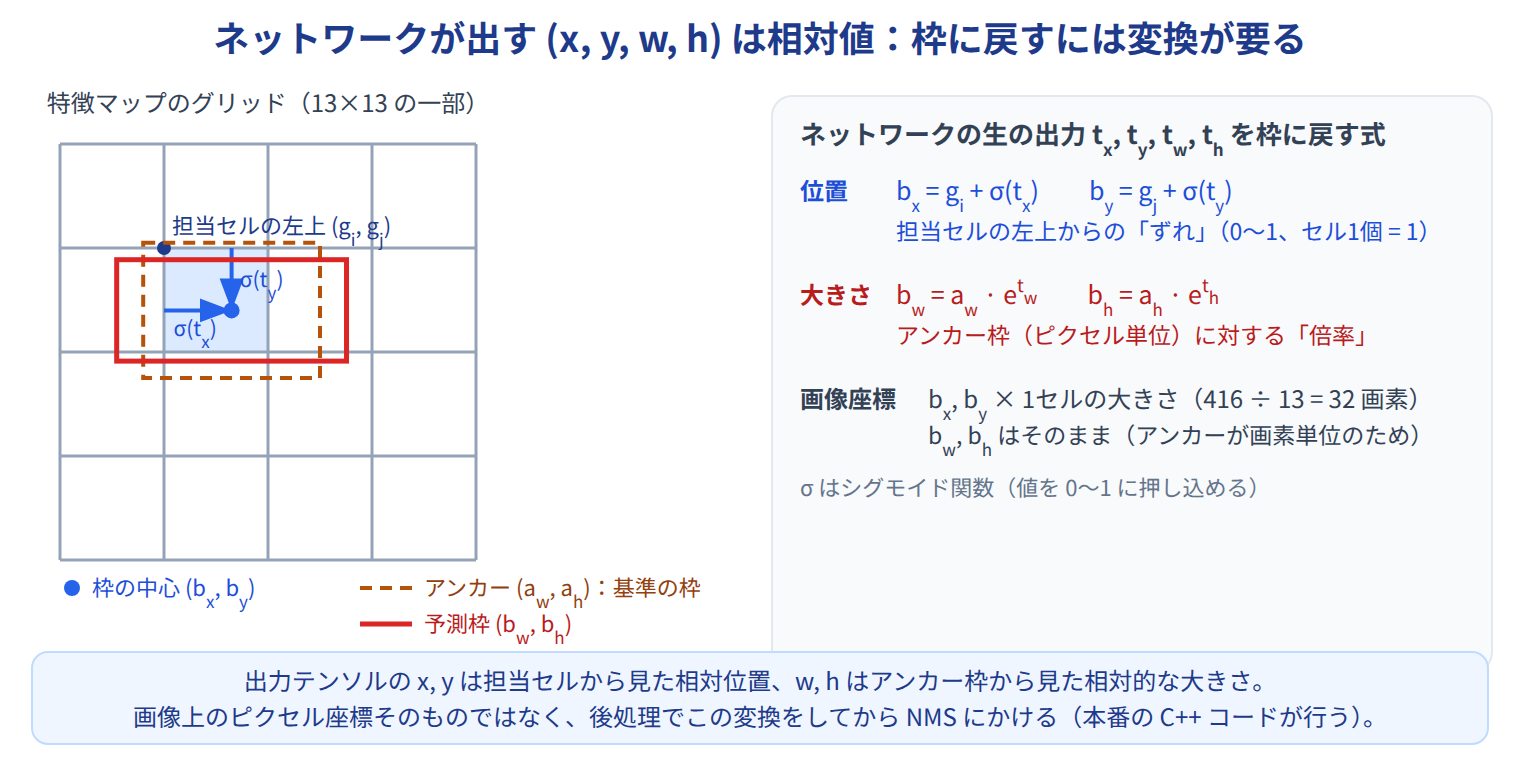

**▲ 図6：出力テンソルの `(x, y, w, h)` から枠を復元する。** `x, y` は担当セルの左上からのずれ（0〜1）、`w, h` はアンカー枠に対する倍率であり、上の式で画像上の枠 `(bx, by, bw, bh)` に戻す。

**NMS（Non-Maximum Suppression）**：候補枠は1万個以上出ますが、本当に欲しいのは「物体1つにつき枠1つ」です。そこで **後処理** として、(1) `objectness × クラススコア` が低い枠を **しきい値で捨て**、(2) 残った枠について **最もスコアの高い枠を採用し、それと大きく重なる（IoUが高い）枠を消す**、という操作を繰り返します。これが **NMS** で、重複した枠を1つにまとめて最終的な検出結果を作ります（本番のC++コードにある `applyNMS` がまさにこの処理です）。

> **NMS をもっと詳しく知りたい人へ（参考）**：手順（スコア順に並べる → 最高スコアの枠を取り出す → IoU を計算 → しきい値を超える枠を削除 → 繰り返し）や複数クラスの扱いが、図つきで丁寧に説明されています。
> 澁谷直樹「Object Detection: Removing redundant Bounding Boxes with Non-Maximum Suppression (NMS)」（note、本文は日本語）
> <https://note.com/kikaben/n/nf4ddafd80492>

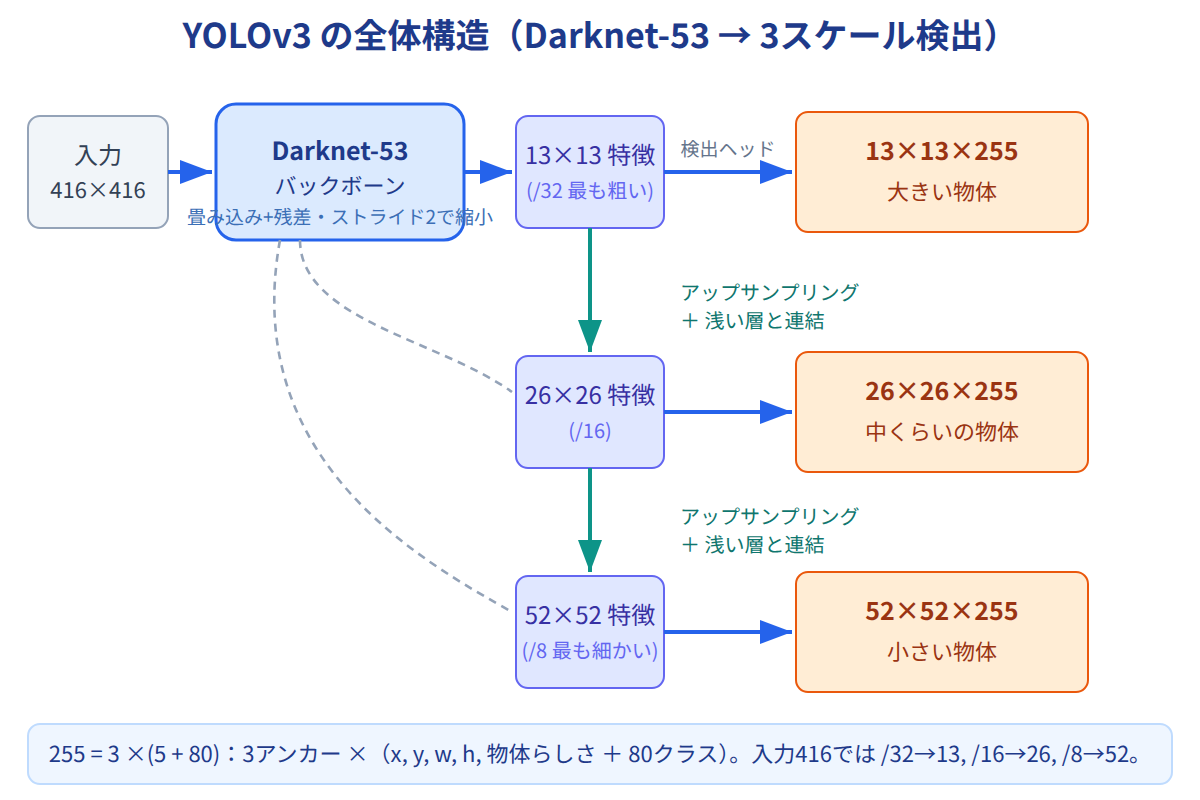

**▲ 図7：YOLOv3の全体構造。** Darknet-53で特徴を抽出しながら縮小し、`13×13`・`26×26`・`52×52` の3つの解像度で検出します。深い特徴（`13×13`）をアップサンプリングして浅い層と連結することで、小さい物体も捉えます（青の実線＝主な流れ、緑＝アップサンプリング＋連結、灰の点線＝浅い層の特徴）。

**yolov3-tiny について（本番でも使用）**：YOLOv3は大きく重いので、より軽い **yolov3-tiny** も本番で使います。tinyは、バックボーンが浅く（畳み込み層が少なく、ダウンサンプリングに **最大プーリング** を使う）、**検出スケールも2つ**（`13×13` と `26×26`）に減らした版です。最も細かい `52×52` スケールが無いぶん、**小さい物体の検出精度（mAP）は下がります** が、計算が軽く **FPS（処理速度）は上がります**（フルのYOLOv3との精度・速度のトレードオフ）。

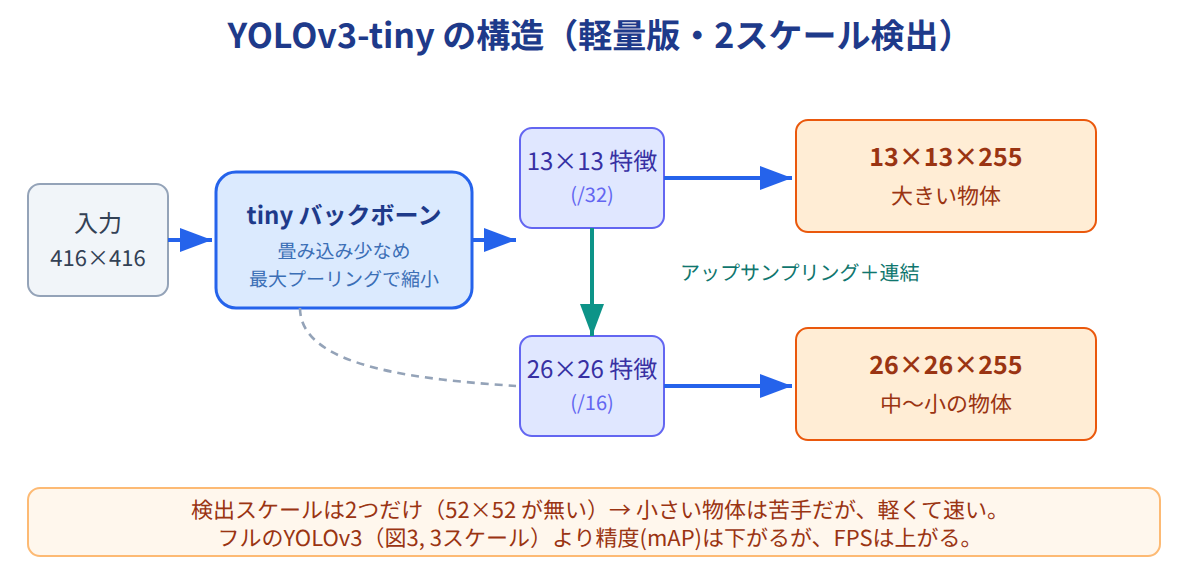

**▲ 図8：YOLOv3-tinyの構造。** バックボーンが浅く、検出は `13×13` と `26×26` の2スケールだけ（図7の3スケールから `52×52` が無い）。軽くて速い反面、小さい物体は苦手です。

**学習についての注意（Google Colab）**：YOLOv3（フル）の学習は計算量が非常に大きく、**Google Colabの無料枠では最後まで終わりません**。無料GPUは利用時間に制限があり一定時間で切断されることがある一方、フルYOLOv3の学習は通常 **数時間〜数日** かかるためです。一方、**yolov3-tiny を入力 `256×256` 程度** に絞れば、無料枠でも現実的な時間で学習を試せる見込みです。本格的な学習は、より制限のゆるい環境（Kaggle、Lightning AI など）や有料GPUを使うのが一般的です（第4章のLeNet/MNISTが軽いのは、ネットワークもデータも小さいからです）。

---

## 設問

### 問11

YOLOv3のバックボーン（Darknet-53）は **全結合層を持たない（fully convolutional）**。これにより得られる利点を1つ挙げよ。また、ダウンサンプリングに **プーリングではなくストライド2の畳み込み** を使っている点を、第1章の出力サイズ公式と関連づけて説明せよ。

### 問12

YOLOv3で多用される **`1×1` 畳み込み** は、何のために使われているか。第3章のpointwise畳み込みと関連づけて答えよ。

### 問13

入力 `416×416`、クラス数 `C=80`、1セルあたりアンカー `B=3` のとき、最も粗いスケールの出力テンソルの形 `グリッド × グリッド × チャネル` はいくつになるか（縮小率は32倍とする）。チャネル数の `255` がどこから来るのかも説明せよ。

### 問14

YOLOv3は1万個以上の候補枠を出す。最終結果にするための後処理 **NMS** は、何のために、どんな操作をするのか説明せよ。

## 設問の解答

### 問11

- **fully convolutional の利点**：全結合層が無いので、各出力が入力の位置に対応する **空間的な配置（グリッド）を保ったまま** 処理が進む。だから「画像のどこに物体があるか」を格子状に（密に）予測でき、検出のように位置が重要なタスクに向く。パラメータも全結合より少なくて済む。（なお実際には、前処理で画像を決まった入力サイズ（例：`416×416`）にリサイズしてからネットワークに入れる。「全結合が無い＝どんなサイズでも勝手に動く」という意味ではない点に注意。）
- **ストライド2の畳み込みでダウンサンプリング**：出力公式 `O = ⌊(W−K+2P)/S⌋+1` で `S=2` にすると出力が **約半分** になる。プーリングのように単純に間引くのではなく、**畳み込みで特徴を抽出しながら同時に縮小** できるため、学習で最適な縮小の仕方を獲得できる。これを繰り返して `416 → 208 → 104 → 52 → 26 → 13` と縮めている（計5回、縮小率32倍）。

### 問12

`1×1` 畳み込み（pointwise）は、空間方向には混ぜず **チャネル方向だけを混ぜ合わせる** 演算。YOLOv3では主に **チャネル数を減らして計算量を抑える**（太いチャネルを一度絞ってから `3×3` を掛ける）ためや、検出ヘッドで **最終的な出力チャネル数（`B×(5+C)`）に整える** ために使われる。第3章のpointwise畳み込みそのもの。

### 問13

- 縮小率32倍なので、`416 ÷ 32 = 13` → グリッドは **`13×13`**。
- チャネル数：`B × (5 + C) = 3 × (5 + 80) = 3 × 85 = 255`。内訳は次のとおり。
- ・`5` は1つの予測枠の `x, y, w, h`（位置とサイズ）＋ `objectness`（物体があるかの確信度）。ただし `x, y` は担当セルの左上からの相対位置、`w, h` はアンカー枠に対する相対的な大きさであり、画像上のピクセル座標ではない（図6）。
- ・`C = 80` はクラスごとのスコア（COCOの80クラス）。
- ・`B = 3` は1セルあたりのアンカー（予測枠）の数。
- よって最も粗いスケールの出力テンソルは **`13 × 13 × 255`**。各セルが3つの枠について「位置・サイズ・物体らしさ・クラス」を予測している。

In [ ]:
# 問13の確認：最も粗いスケールの出力テンソルの形
W_in, stride_total = 416, 32
B, C = 3, 80
grid = W_in // stride_total
ch = B * (5 + C)
print(f"グリッド  : {W_in} / {stride_total} = {grid}  ->  {grid}x{grid}")
print(f"チャネル  : B * (5 + C) = {B} * (5 + {C}) = {ch}")
print(f"出力テンソル : {grid} x {grid} x {ch}")
n_boxes = sum(g * g for g in (13, 26, 52)) * B
print(f"3スケール合計の候補枠 : (13*13 + 26*26 + 52*52) * {B} = {n_boxes:,}")

### 問14

NMSは、**同じ物体に対して重複して出た枠を1つにまとめる** ための後処理。前提として、出力テンソルの相対値 `(x, y, w, h)` はアンカーとセル位置を使って画像上の枠に戻しておく（図6）。手順は、(1) `objectness × クラススコア` が低い枠を **しきい値で捨て**、(2) 残った枠のうち **最もスコアの高い枠を残し、それと大きく重なる（IoUが高い）枠を削除** する、を繰り返す。これにより「物体1つにつき枠1つ」の最終結果になる。本番のC++コードの `applyNMS` がこの処理にあたる。

## まとめ

CNNの基本部品（畳み込み・サイズ変化・チャネル操作・Encoder-Decoder・軽量化）を理解し、それらが組み合わさって YOLOv3 という大きなCNNができていることをつかむこと。本番では、このネットワークをKV260のDPUで高速に動かします。